In [75]:
import numpy as np
from pprint import pprint

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline , Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import (
    SGDClassifier , RidgeClassifier , LogisticRegression , LogisticRegressionCV
)
from sklearn.metrics import (
    log_loss,
    ConfusionMatrixDisplay,
    precision_score , recall_score , classification_report,
    precision_recall_curve , roc_curve , roc_auc_score
)

from sklearn.model_selection import (
    cross_validate,
    RandomizedSearchCV,
    GridSearchCV                 
)

from scipy.stats import loguniform

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns


In [76]:
from sklearn.datasets import fetch_openml
x_pd , y_pd = fetch_openml('mnist_784' , version=1 , return_X_y=True)
x = x_pd.to_numpy()
y = y_pd.to_numpy()

scaler = MinMaxScaler()
X = scaler.fit_transform(x)

target_names = np.unique(y)

x_train, x_test, y_train, y_test = X[ :60000], X[60000 : ] , y[ : 60000], y[ 60000 : ]

y_train_0 = np.zeros(len(y_train))
y_test_0 = np.zeros(len(y_test))

index_0 = np.where(y_train=='0')
y_train_0[index_0] = 1

index_0 = np.where(y_test=='0')
y_test_0[index_0] = 1

### Logistic Regression in Scikit-Learn: Under the Hood

#### 1. Weights Dhundhne ke Do Tarike (SGD vs Solvers)
Pichle lecture mein tumne `SGDClassifier` use kiya tha, jo ek **iterative** tarika hai. Iterative ka matlab hai ki wo ek chota kadam leta hai, dekhta hai error kam hua ya nahi, aur fir agla kadam leta hai (Gradient Descent). 

Lekin Logistic Regression ko train karne ka ek aur mathematical tarika hota hai: **Direct Equation Solve Karna.**
Hame pata hai ki hume loss (error) ko minimum karna hai. Calculus ka basic rule kehta hai ki jahan pahad ki dhalan (slope/derivative) zero hoti hai, wahan minimum point hota hai. 
Toh math ke hisaab se hum loss ($L$) ka weights ($w$) ke respect mein derivative nikal kar usko $0$ ke equal rakh sakte hain:
$$\frac{\partial L}{\partial w} = 0$$

**Problem Kya Hai?**
Linear regression mein yeh equation solve karna bohot asaan hota hai (isko Normal Equation bolte hain). Lekin Logistic Regression mein humne **Sigmoid** function ($\frac{1}{1 + e^{-z}}$) lagaya tha. Is Sigmoid ki wajah se equation bohot complex aur *non-linear* ho jati hai. Tum ek simple formula laga kar $w$ ki value nahi nikal sakte. Isliye hume special math solvers ki zarurat padti hai.

#### 2. Sklearn ke "Solvers" (lbfgs, sag, saga, liblinear)
Kyunki direct equation solve nahi ho sakti, Scikit-Learn mein advanced optimization algorithms (Solvers) dale gaye hain. Ye algorithms calculus aur matrix math ka use karke us non-linear equation ka closest answer dhundhte hain.

*   **`liblinear`:** Chhote datasets ke liye accha hai.
*   **`sag` aur `saga`:** (Stochastic Average Gradient) Ye bade datasets (large data) par bohot fast hote hain.
*   **`lbfgs` (Default):** Ye memory-efficient math use karta hai aur mostly har tarah ke classification problems par best default result deta hai. 
*   **`newton-cg`:** Ye sirf slope (1st derivative) nahi, balki curve ki shape (2nd derivative / Hessian matrix) bhi dekhta hai, par slow hota hai.

#### 3. Default Regularization (The Secret Trap)
Sklearn ki Logistic Regression mein ek bohot bada "gotcha" (trap) hai jo bohot log miss kar dete hain: **Sklearn mein Regularization by default ON hoti hai.** 
Agar tum default parameters dekho: `penalty='l2'` likha hai. 
Iska matlab algorithm automatically weights ($w$) ko bohot bada hone se rok raha hai taaki model *Overfit* na kare. Ye loss function mein ek penalty add kar deta hai:
$$Loss = \text{Original Loss} + \lambda \sum w^2$$

#### 4. The Parameter 'C' (Regularization ka Remote Control)
Formula mein jo $\lambda$ (lambda) hai, wo tay karta hai ki penalty kitni lagani hai. Lekin Scikit-learn mein $\lambda$ ki jagah **`C`** parameter use hota hai.
In dono ka math relation ulta (inverse) hota hai:
$$C = \frac{1}{\lambda}$$

*   **Agar `C` bohot chota hai (e.g., 0.01):** Matlab $\lambda$ bohot bada hai. Tum model par bohot strict penalty laga rahe ho (Strong Regularization).
*   **Agar `C` bada hai (e.g., 100):** Matlab $\lambda$ bohot chota hai. Tum model ko thodi chhoot de rahe ho (Weak Regularization).
*   **Default `C=1.0`:** Ye ek balanced state hai.

#### 5. Bina Regularization ka Model Banana
Lecture ke end mein bataya gaya hai ki agar hume strictly bina regularization ka model (jaise SGDClassifier bina penalty ke hota hai) banana ho, toh hume `C` ko infinity ($\infty$) par set karna padega. 

Math ke hisaab se:
Agar $C = \infty$, toh $\lambda = \frac{1}{\infty} = 0$.
Jab penalty weight ($\lambda$) hi $0$ ho gaya, toh equation mein se regularization wala part gayab ho jayega:
$$Loss = \text{Original Loss} + (0 \times \sum w^2)$$
Python/Sklearn mein isko implement karne ke liye hum normally `C=np.inf` ya koi bohot bada number (jaise `C=1e9`) set kar dete hain.

#### Training without Regularization , by setting c=infinity (lambda=0)

In [77]:
pipe_logit = make_pipeline(
    MinMaxScaler(),
    LogisticRegression(
        random_state=1729,
        solver='lbfgs',
        penalty=None
    )   
)

pipe_logit.fit(x_train , y_train_0)

c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('minmaxscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=

#### Hyperparameter Search with GridSearchCV

In [78]:
grid_Cs = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]

scaler = MinMaxScaler()

logreg = LogisticRegression(
    C=1.0 , random_state=1729,
)

pipe = Pipeline([
    ("scaler" , scaler),
    ("logistic" , logreg)
])

pipe_logit_cv = GridSearchCV(
    pipe,
    param_grid={"logistic__C":grid_Cs},
    scoring="f1"
)

pipe_logit_cv.fit(x_train , y_train_0)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=1729))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logistic__C': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and ca

In [79]:
pipe_logit_cv.best_params_

{'logistic__C': 0.1}

In [80]:
pipe_logit_cv.best_score_

np.float64(0.9582781080330685)

In [81]:
pipe_logit_cv.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pur

In [82]:
estimator = LogisticRegressionCV(cv=5 , scoring='f1' , random_state=1729)
logit_cv = make_pipeline(
    MinMaxScaler() , estimator
)
logit_cv.fit(x_train , y_train_0)

c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.w

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('minmaxscaler', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=No

#### Performance Evaluation

#### precision , recall , f1-score

#### Let's evaluate performance of these three different logistic regression classifiers for detecting digit 0 from the image.

* Logistic regression without regularization.
* Best logistic regression classifier found through GridSearchCV.
* Best classifier found through LogisticRegressionCV.

`Note` that GridSearchCV and LogisticRegressioncv by default refit the classifier for the best hyperparameter values.

In [83]:
lr_y_hat_0 = pipe_logit.predict (x_test)
lr_gs_y_hat_0 = pipe_logit_cv.best_estimator_.predict(x_test)
lr_cv_y_hat_0 = logit_cv.predict(x_test)

precision_lr = precision_score(y_test_0, lr_y_hat_0)
recall_lr = recall_score(y_test_0, lr_y_hat_0)

precision_lr_gs = precision_score(y_test_0, lr_gs_y_hat_0)
recall_lr_gs = recall_score(y_test_0, lr_gs_y_hat_0)

precision_lr_cv = precision_score(y_test_0, lr_cv_y_hat_0)
recall_lr_cv = recall_score(y_test_0, lr_cv_y_hat_0)

print (f"LogReg: precision={precision_lr}, recall={recall_lr}")
print (f"GridSearch: Iprecision={precision_lr_gs}, recall={recall_lr_gs}")
print (f"LogRegCV: precision={precision_lr_cv}, recall={recall_lr_cv}")

LogReg: precision=0.9544994944388271, recall=0.963265306122449
GridSearch: Iprecision=0.9555555555555556, recall=0.9653061224489796
LogRegCV: precision=0.9526686807653575, recall=0.9653061224489796


In [84]:
y_scores_lr = pipe_logit.decision_function(x_test)
precisions_lr , recalls_lr , thresholds_lr = precision_recall_curve(
    y_test_0 , y_scores_lr
)

y_scores_lr_gs = pipe_logit_cv.decision_function(x_test)
precisions_lr_gs , recalls_lr_gs , thresholds_lr_gs = precision_recall_curve(
    y_test_0 , y_scores_lr_gs
)

y_scores_lr_cv = logit_cv.decision_function(x_test)
precisions_lr_cv , recalls_lr_cv , thresholds_lr_cv = precision_recall_curve(
    y_test_0 , y_scores_lr_cv
)

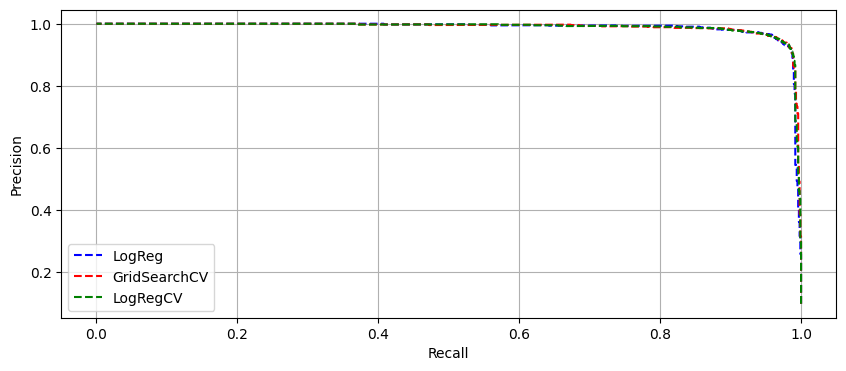

In [85]:
plt.figure(figsize=(10,4))
plt.plot(recalls_lr[ :-1], precisions_lr[ :-1], 'b--', label='LogReg')
plt.plot(recalls_lr_gs[ :-1], precisions_lr_gs[ :-1], 'r--', label='GridSearchCV')
plt.plot(recalls_lr_cv[ :-1], precisions_lr_cv[ :-1], 'g--', label='LogRegCV' )

plt.ylabel('Precision')
plt.xlabel('Recall')
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

#### Calculate Area of PR curve

In [86]:
from sklearn.metrics import auc

auc_lr = auc(recalls_lr[ :-1], precisions_lr[ :-1])
auc_lr_gs = auc(recalls_lr_gs[ :-1], precisions_lr_gs[ :-1])
auc_lr_cv = auc(recalls_lr_cv[ :-1], precisions_lr_cv[ :-1])

In [87]:
print ("AUC-PR for logistic regression:", auc_lr)
print ("AUC-PR for grid search:", auc_lr_gs)
print ("AUC-PR for logistic regression CV:", auc_lr_cv)

AUC-PR for logistic regression: 0.9872513414335627
AUC-PR for grid search: 0.9884540467590754
AUC-PR for logistic regression CV: 0.988268233759997


#### Confusion Matrix : LogisticRegression Classifier

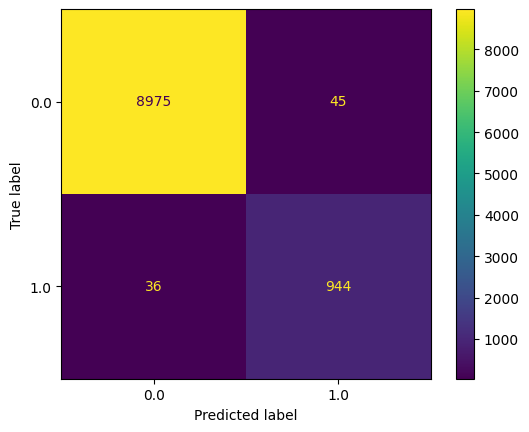

In [88]:
cm_display = ConfusionMatrixDisplay. from_predictions(y_test_0, lr_y_hat_0,values_format='.5g')

# it return matplotlin plot object
plt.show()

#### Confusion Matrix : GridSearchCV

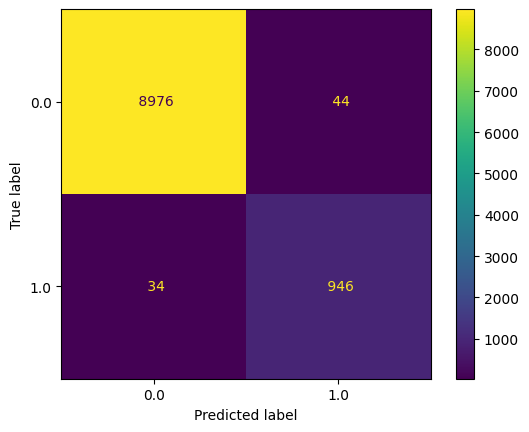

In [89]:
cm_display = ConfusionMatrixDisplay. from_predictions(y_test_0, lr_gs_y_hat_0, values_format=' .5g' )

# it return matplotlin plot object
plt.show()

#### ConfusionMatrix : CrossValidation

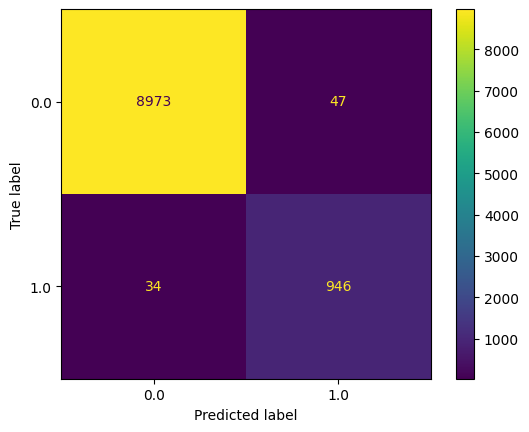

In [90]:
cm_display = ConfusionMatrixDisplay. from_predictions(y_test_0, lr_cv_y_hat_0, values_format='.5g' )

# it return matplotlin plot object
plt.show()